<a href="https://colab.research.google.com/github/ArthurCBx/Applied_MachineLearning_in_Python/blob/main/Module1/Fundamentals_of_ML_Intro_Scikit_Learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction**

## What is ML ?
- The study of computer programs (algorithms) that can learn by example
- ML algorithms can generalize from existing examples of a task

## Experience on ML models
- Labeled examples
- User feedback
- Surrounding environment (self-driving car)

## ML brings together:
- Statistical methos:
 - Infer conclusions from data;
 - Estimate reliability of predictions.
- Computer Science:
 - Large-scale computing architectures;
 - Algorithms for capturing, manipulating, indexing, combining, retrieving and performing predictions on data;
 - Software pipelines that manage the complexity of multiple subtasks.
- Economics, biology, psychology ...

# **Key Concepts in ML**

## Supervised Learning
> Learn to predict target values from labelled data

> Types:
- Classification (discrete values)
- Regression (continuous values)

> Where do labels come from:
 - Human workers


## Unsupervised Learning

Find structure in unlabeled data:
 - Find group of similar instances in the data (clustering);
 - Finding unusual patterns (outlier detection).

## Basic Machine Learning Workflow
1. Representation: Choose a feature representation and type of classifiers to use. E.g. image represented by an array of pixel.
2. Evaluation: Choose what criterion distinguishes good vs bad classifiers. E.g. % correct predictions on a set.
3. Optimization: Choose how to search for the settings/parameters that give the best classifier for this evaluation criterion. E.g. try a range of values for 'k' parameter in k-nearest neighbor classifier

# Python Tools for ML
- Scikit-learn
- Matplotlib
- SciPy
- Numpy
- Pandas
- Seaborn

In [ ]:
import sklearn as sk
import scipy as sp
import seaborn as sea
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
versions = [sk.__version__, sp.__version__,sea.__version__,np.__version__,pd.__version__,mpl.__version__]
versions

['1.6.1', '1.16.1', '0.13.2', '2.0.2', '2.2.2', '3.10.0']

# **An Example ML Problem**

In [ ]:
!git clone -q https://github.com/ArthurCBx/Applied_MachineLearning_in_Python.git

In [ ]:
from sklearn.model_selection import train_test_split

fruits = pd.read_table('Applied_MachineLearning_in_Python/Module1/data/fruit_data_with_colors.txt')

fruits

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79
5,2,mandarin,mandarin,80,5.8,4.3,0.77
6,2,mandarin,mandarin,80,5.9,4.3,0.81
7,2,mandarin,mandarin,76,5.8,4.0,0.81
8,1,apple,braeburn,178,7.1,7.8,0.92
9,1,apple,braeburn,172,7.4,7.0,0.89


In [ ]:
lookup_fruit_name = dict(zip(fruits.fruit_label.unique(),fruits.fruit_name.unique()))
lookup_fruit_name


{np.int64(1): 'apple',
 np.int64(2): 'mandarin',
 np.int64(3): 'orange',
 np.int64(4): 'lemon'}

## Creating train and test split

In [ ]:
X = fruits[['mass','width','height', 'color_score']]
y = fruits['fruit_label']

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=0)

# Examining the Data

/tmp/ipython-input-2111873939.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('gnuplot')


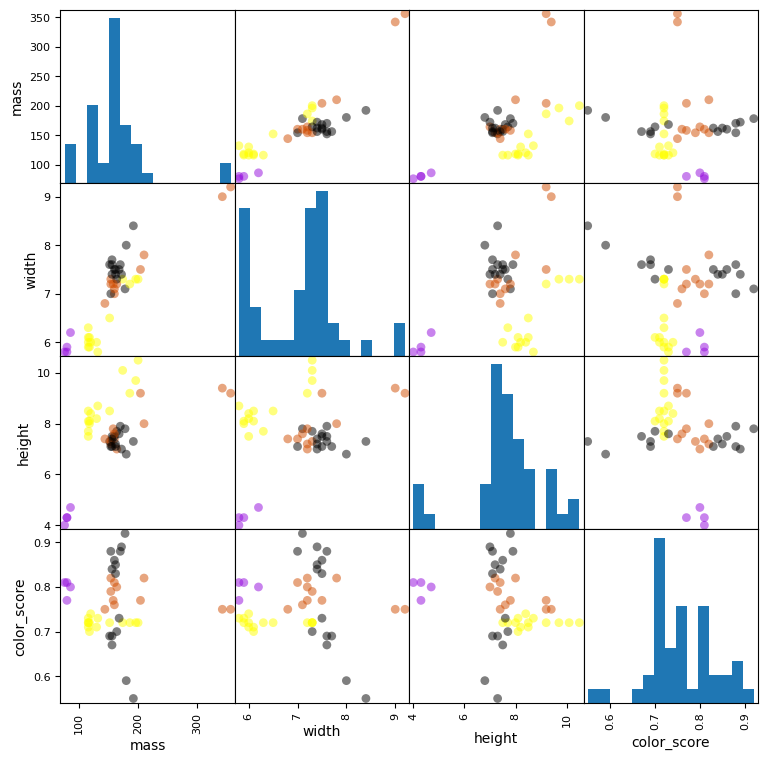

In [ ]:
cmap = plt.cm.get_cmap('gnuplot')
scatter = pd.plotting.scatter_matrix(X_train,c=y_train,marker='o',s=40,hist_kwds={'bins':15},figsize=(9,9),cmap=cmap)

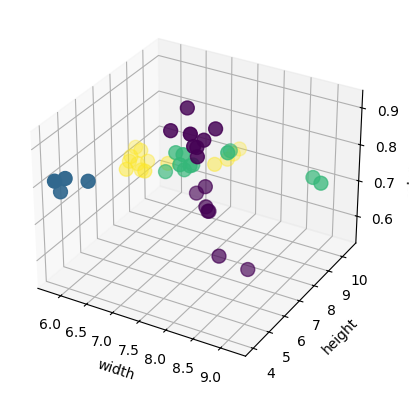

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.scatter(X_train['width'],X_train['height'],X_train['color_score'],c=y_train,marker='o',s=100)
ax.set_xlabel('width')
ax.set_ylabel('height')
ax.set_zlabel('color_score')
plt.show()

# **K-Nearest Neighbors Classification**

Can be used for classification and regression

## k-NN Classifier Algorithm

Given a training set X_train with labels y_train, and given a new instance x_test to be classified:
1. Find the most similar instances (let's call them X_NN) to x_test that are in X_train;
2. Get the labels y_NN for the instances in X_NN;
3. Predict the label for x_test by combining the labels y_NN e.g. simple majority vote.

Four things need to be specified to run a k-NN algorithm:
1. A distance metric; (E.g. Euclidean)
2. How many 'nearest' neighbors to look at?
3. Optional weighting function on the neighbor points;
4. Method for aggregating the classes of neighbor points. (E.g majority vote)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Creating the model
knn = KNeighborsClassifier(n_neighbors=5,n_jobs=-1) # Only specified n2. The default for the others are Euclidean and majority vote

# Training the model
knn.fit(X_train, y_train)

KNeighborsClassifier(n_jobs=-1)

In [ ]:
# Get the accuracy of the classifier on the test data
knn.score(X_test,y_test)

0.5333333333333333

In [ ]:
# Testing the model on a new info
fruit_prediction = knn.predict([[20,4.3,5.5, 0.88]])
lookup_fruit_name[fruit_prediction[0]]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


'mandarin'

In [ ]:
fruit_prediction = knn.predict([[100,6.3,8.5, 0.2]])
lookup_fruit_name[fruit_prediction[0]]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


'lemon'

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


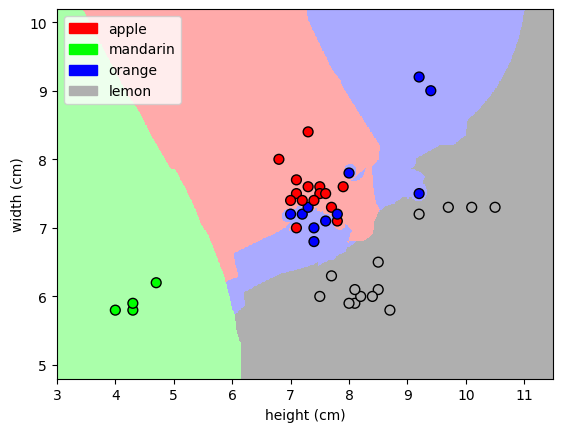

In [ ]:
# Plotting the decision boundaries of the model
from Applied_MachineLearning_in_Python.Module1.adspy_shared_utilities import plot_fruit_knn

plot_fruit_knn(X_train,y_train,5,'distance');

### How sensitive is k-NN classification accuracy to the choice of the 'k' parameter?


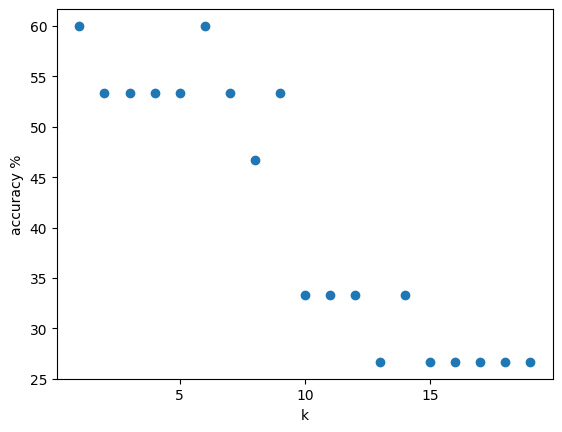

In [ ]:
k_range = np.arange(1,20)
scores = np.array([])

for k in k_range:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train,y_train)
  scores = np.append(scores, knn.score(X_test,y_test))

scores = 100*scores
plt.figure()
plt.xlabel('k')
plt.ylabel('accuracy %')
plt.xticks([0,5,10,15,20]);
plt.scatter(k_range,scores);

# Assignment 1

In [ ]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

print(cancer.DESCR) # Print the data set description

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(cancer.data,cancer.target,random_state=0)

## Question 0 (Example)

How many features does the breast cancer dataset have?

*This function should return an integer.*

In [ ]:
cancer.data.shape

(569, 30)

In [ ]:
def answer_zero():
  # This function returns the number of features of the breast cancer dataset, which is an integer.
  # The assignment question description will tell you the general format the autograder is expecting
  return cancer.data.shape[1]


## Question 1

Scikit-learn works with lists, numpy arrays, scipy-sparse matrices, and pandas DataFrames, so converting the dataset to a DataFrame is not necessary for training this model. Using a DataFrame does however help make many things easier such as munging data, so let's practice creating a classifier with a pandas DataFrame.



Convert the sklearn.dataset `cancer` to a DataFrame.

*This function should return a `(569, 31)` DataFrame with *

*columns = *

    ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
    'mean smoothness', 'mean compactness', 'mean concavity',
    'mean concave points', 'mean symmetry', 'mean fractal dimension',
    'radius error', 'texture error', 'perimeter error', 'area error',
    'smoothness error', 'compactness error', 'concavity error',
    'concave points error', 'symmetry error', 'fractal dimension error',
    'worst radius', 'worst texture', 'worst perimeter', 'worst area',
    'worst smoothness', 'worst compactness', 'worst concavity',
    'worst concave points', 'worst symmetry', 'worst fractal dimension',
    'target']

*and index = *

    RangeIndex(start=0, stop=569, step=1)

In [ ]:
def answer_one():
  pd_target = pd.Series(cancer.target,name='target')
  pd_values = pd.DataFrame(cancer.data, columns=cancer.feature_names)
  return pd.concat([pd_values,pd_target],axis=1)
answer_one()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


## Question 2
What is the class distribution? (i.e. how many instances of `malignant` and how many `benign`?)

*This function should return a Series named `target` of length 2 with integer values and index =* `['malignant', 'benign']`

In [ ]:
from os import name
def answer_two():
  df = answer_one()
  return pd.Series(df['target'].value_counts(),name='target').rename(index={0:'malignant',1:'benign'})
answer_two()

,target
target,
benign,357
malignant,212


## Question 3
Split the DataFrame into `X` (the data) and `y` (the labels).

*This function should return a tuple of length 2:* `(X, y)`*, where*
* `X` *has shape* `(569, 30)`
* `y` *has shape* `(569,)`.

In [ ]:
def answer_three():
  X,y = answer_one().iloc[:,:-1],answer_one().iloc[:,-1]
  return (X,y)

## Question 4
Using `train_test_split`, split `X` and `y` into training and test sets `(X_train, X_test, y_train, and y_test)`.

**Set the random number generator state to 0 using `random_state=0` to make sure your results match the autograder!**

*This function should return a tuple of length 4:* `(X_train, X_test, y_train, y_test)`*, where*
* `X_train` *has shape* `(426, 30)`
* `X_test` *has shape* `(143, 30)`
* `y_train` *has shape* `(426,)`
* `y_test` *has shape* `(143,)`

In [ ]:
from sklearn.model_selection import train_test_split

def answer_four():
  X,y = answer_three()
  X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=0)
  return (X_train, X_test, y_train, y_test)


## Question 5
Using KNeighborsClassifier, fit a k-nearest neighbors (knn) classifier with `X_train`, `y_train` and using one nearest neighbor (`n_neighbors = 1`).

*This function should return a `sklearn.neighbors.classification.KNeighborsClassifier`.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

def answer_five():
  X_train, X_test, y_train, y_test = answer_four()
  model = KNeighborsClassifier(n_neighbors=1)
  model.fit(X_train,y_train)
  return model
answer_five()

KNeighborsClassifier(n_neighbors=1)

## Question 6
Using your knn classifier, predict the class label using the mean value for each feature.

Hint: You can use `cancerdf.mean()[:-1].values.reshape(1, -1)` which gets the mean value for each feature, ignores the target column, and reshapes the data from 1 dimension to 2 (necessary for the precict method of KNeighborsClassifier).

In [ ]:
def answer_six():
  df = answer_one()
  model = answer_five()
  df = df.mean()[:-1].values.reshape(1,-1)
  df = pd.DataFrame(df,columns=answer_one().columns[:-1])
  return model.predict(df).item()
answer_six()

1

## Question 7
Using your knn classifier, predict the class labels for the test set `X_test`.

*This function should return a numpy array with shape `(143,)` and values either `0.0` or `1.0`.*

In [ ]:
def answer_seven():
  model = answer_five()
  X_train, X_test, y_train, y_test = answer_four()
  return model.predict(X_test)


array([1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0])

## Question 8
Find the score (mean accuracy) of your knn classifier using `X_test` and `y_test`.

*This function should return a float between 0 and 1*

In [ ]:
def answer_eight():
  X_train, X_test, y_train, y_test = answer_four()
  predict_label = answer_seven()
  return np.mean(predict_label == y_test)
answer_eight()

np.float64(0.916083916083916)